<img src="https://www.javeriana.edu.co/recursosdb/20125/5571273/escudo-circular.png" alt="Your Image" style="float:left;">
</div><h1>Pontificia Universidad Javeriana</h1>

<h1>Evaluación sumativa grupal – Detección de fraude</h1>

<h1>Grupo 1 SinergIA</h1>

Link base de datos:

https://www.kaggle.com/datasets/ealaxi/paysim1?resource=download


## **1	Comprensión del negocio**

### **1.1.	Objetivos**

>
* Describir y analizar el conjunto de datos de fraude

* Entender cuales son las variables más relevantes para obtener una predicción.

* Desarrollar un modelo de predicción con base en la información suministrada.




### **1.2.	Descripción**

> Existe una limitada disponibilidad de conjuntos de datos públicos en el ámbito de los servicios financieros, especialmente en dominios emergentes como las transacciones de dinero móvil. Este tipo de información resulta fundamental para la investigación, particularmente en áreas como la detección de fraude. Sin embargo, una de las principales dificultades radica en la naturaleza altamente privada y sensible de las transacciones financieras, lo que restringe el acceso a datos reales y limita el desarrollo de soluciones robustas.

> Como alternativa a esta problemática, se propone el uso de datos sintéticos generados mediante simulación. Estos conjuntos de datos se construyen a partir de información agregada proveniente de fuentes privadas, con el objetivo de replicar el comportamiento habitual de las transacciones. Adicionalmente, se incorporan patrones de comportamiento fraudulento de manera controlada, lo que permite evaluar y validar el desempeño de distintos modelos de detección de fraude en un entorno seguro y accesible.

### **1.3. Entidad Financiera: Banco Falabella Colombia**

**Banco Falabella** es una entidad financiera de origen chileno, subsidiaria del Grupo Falabella, uno de los conglomerados retail más grandes de América Latina. En Colombia opera bajo la vigilancia de la **Superintendencia Financiera de Colombia (SFC)** y está especializado en productos de crédito al consumo, con la **Tarjeta CMR** como producto insignia.

#### Perfil Financiero
- **Segmento:** Crédito al consumo masivo, vinculado al ecosistema retail de Falabella.
- **Producto principal:** Tarjeta de crédito CMR Falabella, orientada a clientes de estratos medios con perfil de compra en tiendas físicas y canales digitales.
- **Exposición al fraude:** Alta, por la naturaleza del producto (transacciones sin tarjeta presente – CNP), el volumen masivo de transacciones en e-commerce y la diversidad del perfil de sus clientes, que incluye segmentos con historial crediticio delgado (*thin-file*).
- **Supervisión:** Vigilado por la SFC, sujeto al régimen de SARLAFT (Sistema de Administración del Riesgo de Lavado de Activos y Financiación del Terrorismo).

#### Perfil Técnico y Operacional
- Canales digitales activos: aplicación móvil, portal web, integración con plataforma Falabella.com.co.
- Procesamiento de pagos en redes internacionales (Visa/Mastercard), implicando millones de transacciones en tiempo real.
- El volumen transaccional hace inviable la auditoría manual del 100% de las operaciones, justificando la implementación de sistemas de IA para detección de fraude.
- Obligado por la Circular Básica Jurídica de la SFC (Circular Externa 29 de 2014 y actualizaciones 2024) a tener procedimientos de bloqueo preventivo con canales expeditos de reactivación para el cliente.

### **1.4. Marco Legal Aplicable a Banco Falabella**

El despliegue de modelos de IA para detección de fraude en Banco Falabella opera en la intersección de múltiples marcos normativos colombianos.

---

#### Código Penal Colombiano (Ley 599 de 2000)

| Artículo | Delito | Implicación para Banco Falabella |
|----------|--------|----------------------------------|
| **Art. 246** | Estafa | El banco debe detectar y prevenir maniobras engañosas para obtener provecho ilícito. El modelo de IA es el mecanismo de detección. |
| **Art. 316** | Captación masiva y habitual de dineros | Obliga a controles estrictos sobre el flujo de fondos. |
| **Art. 323** | Lavado de activos | Exige monitorear transacciones sospechosas y reportarlas a la UIAF bajo SARLAFT. La omisión configura **posición de garante**. |
| **Art. 327** | Enriquecimiento ilícito de particulares | La omisión de controles deriva en responsabilidades penales y administrativas ante la SFC y la UIAF. |

> **Posición de garante:** La omisión de controles antifraude en Banco Falabella no es un simple error operacional: activa responsabilidad penal institucional. La IA es un escudo legal indispensable.

---

#### Código Civil Colombiano

**Art. 2341 – Responsabilidad Civil Extracontractual**

La Corte Suprema de Justicia (sentencias SC16496-2016 y SC976-2004) estableció que el contrato bancario conlleva un **deber intrínseco de seguridad y protección**. Si el modelo genera un **falso negativo** (fraude consumado no detectado), Banco Falabella está obligado jurídicamente a **restituir íntegramente los fondos al cliente**. La única excepción es demostrar culpa exclusiva e inexcusable del titular.

---

#### Constitución Política de Colombia

**Art. 15 – Derecho Fundamental al Hábeas Data**

Un **falso positivo** (bloqueo de transacción legítima) genera colisión constitucional directa:
- Restringe el **derecho al mínimo vital** del ciudadano (acceso a alimentación, salud, economía).
- El reporte erróneo como actividad 'sospechosa' vulnera los principios de **veracidad y circulación restringida** de la **Ley 1266 de 2008** (Hábeas Data Financiero).
- La Corte Constitucional (T-255/22, T-113/25) califica los bloqueos prolongados sin justificación como de **altísima gravedad**, especialmente en cuentas de nómina o mesadas pensionales.

---

#### Normativa de Protección al Consumidor Financiero

- **Ley 1328 de 2009, Art. 3:** Principio de debida diligencia. Banco Falabella debe prestar el servicio con los más altos estándares de seguridad y calidad.
- **Circular SFC 29/2014 y actualizaciones 2024:** Autoriza bloqueos preventivos ante patrones anómalos, pero **exige un procedimiento expedito, transparente y accesible de reactivación**. El bloqueo sin mecanismo de desbloqueo carece de legalidad.

### **1.5. Debido Proceso Institucional en Banco Falabella**

Cuando el modelo clasifica erróneamente una transacción, Banco Falabella debe activar un **debido proceso integral** en tres dimensiones:

#### Dimensión Técnica
El clasificador debe contar con un **umbral de decisión dinámico y matemáticamente justificado**. Esta es precisamente la razón por la que el presente taller evalúa tres umbrales de corte:

| Threshold | Política | Efecto en el cliente |
|-----------|----------|---------------------|
| **0.2** | Alta sensibilidad – detecta más fraude | Más falsos positivos → más bloqueos a clientes legítimos |
| **0.5** | Equilibrio estándar | Balance entre detección y fricción |
| **0.78** | Alta especificidad – menos alarmas | Menos bloqueos, pero más fraudes no detectados |

#### Dimensión Operacional
- Un bloqueo automático debe generar **notificación en tiempo real** al cliente (SMS, push, correo).
- Debe ofrecer canal de **validación multifactorial** (biometría, token) para reactivación en minutos.
- La carga probatoria de la rectificación **no puede recaer sobre el ciudadano** (SFC, Concepto 2024012094-001).

#### Dimensión Legal y Jurisdiccional
- Banco Falabella no ejerce funciones de juzgamiento: no puede bloquear indefinidamente sin fundamento.
- Bloqueos prolongados que afecten cuentas de nómina activan **Acción de Tutela** (T-716/17, T-479/23).
- Si el análisis posterior confirma la sospecha, se activa el reporte obligatorio de **operaciones sospechosas a la UIAF**.

### **1.6. Implicaciones Éticas de la Toma de Decisiones con IA**

La automatización de la decisión de bloquear o permitir transacciones en Banco Falabella representa una **transferencia de poder desde el juicio humano hacia sistemas matemáticos**, con consecuencias directas sobre los derechos fundamentales de los ciudadanos.

#### Riesgo de Sesgo Algorítmico
Los modelos entrenados con datos históricos pueden **perpetuar desigualdades sociodemográficas** preexistentes. En Banco Falabella, cuya base de clientes incluye perfiles con historiales de crédito incipientes (*thin-file*), existe riesgo de que el modelo:
- Penalice sistemáticamente clientes con patrones de uso atípicos pero legítimos.
- Discrimine perfiles geográficos o socioeconómicos históricamente subrepresentados.

Este sesgo viola el principio de **Fairness** del marco **FAccT** (Fairness, Accountability, Transparency), respaldado por la OCDE y la literatura académica especializada.

#### El Dilema de la Caja Negra
Modelos como Random Forest y CatBoost logran alta precisión a costa de **opacidad matemática**. Ante un juez de tutela o la SFC, Banco Falabella no puede responder que *'el algoritmo lo decidió'*. El ciudadano afectado tiene derecho constitucional a conocer la razón de la decisión adversa.

La solución técnica recomendada es **XAI (Explainable AI)** mediante:
- **SHAP** (SHapley Additive exPlanations): cuantifica la contribución de cada variable a la predicción.
- **LIME** (Local Interpretable Model-Agnostic Explanations): aproxima el comportamiento local del modelo de forma humanamente comprensible.

> La integración de modelos de alto rendimiento con herramientas de explicabilidad como SHAP y LIME concilia el rigor científico con el cumplimiento irrestricto de los derechos del consumidor financiero colombiano.

**Referencias:** Marco teórico completo en `docs/investigacion_marco_teorico.pdf` (98 fuentes académicas y jurídicas).

## **2	Estudio y comprensión de datos**

> A continuación se analiza de forma descriptiva el conjunto de datos

**Diccionario de variables – PaySim**

**step**: Unidad de tiempo en horas. Cada valor representa una hora dentro de la simulación (hasta 744 horas, equivalente a 30 días).

**type**: Tipo de transacción realizada. Puede tomar los valores: CASH-IN, CASH-OUT, DEBIT, PAYMENT y TRANSFER.

**amount**: Monto de la transacción.

**nameOrig**: Identificador del cliente que origina la transacción.

**oldbalanceOrg**: Saldo de la cuenta del cliente origen antes de la transacción.

**newbalanceOrig**: Saldo de la cuenta del cliente origen después de la transacción.

**nameDest**: Identificador del cliente que recibe la transacción.

**oldbalanceDest**: Saldo de la cuenta destino antes de la transacción.

**newbalanceDest**: Saldo de la cuenta destino después de la transacción.

**isFraud**: Variable objetivo del modelo. Toma el valor 1 si la transacción es fraudulenta y 0 en caso contrario.

**isFlaggedFraud**: Indica si la transacción fue marcada como sospechosa por el sistema basado en reglas (por ejemplo, montos muy altos).

### **2.1.	Importar Librerías**

> Se Importan paquetes de manejo de datos, modelamiento de algoritmos, procesamiento de datos, visualización y algunas configuraciones para visualización de datos.


In [1]:
# instalamos pandas_profiling para construir un resumen de la base de datos
! pip install https://github.com/pandas-profiling/pandas-profiling/archive/master.zip

  Using cached https://github.com/pandas-profiling/pandas-profiling/archive/master.zip
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
## Manejo de tablas/datos y matrices
import numpy as np
import pandas as pd

## Preprocesamiento y metricas
from sklearn.preprocessing import StandardScaler, Normalizer, scale
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score
)

## Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

## Balanceo de clases
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

## CatBoost
from catboost import CatBoostClassifier

## Visualizacion
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

## Configuracion de visualizacion
%matplotlib inline
mpl.style.use("ggplot")
sns.set_style("white")
pylab.rcParams["figure.figsize"] = 8, 6

print("Librerias cargadas correctamente.")

### **2.2.	Cargar la información**

> Cargamos y leemos la base que se compone por 6.362.620 filas y 11 columnas (7 continuas, 1 discreta y 3 categórica)

In [3]:
# Carga con dtypes optimizados para reducir uso de RAM
# El dataset completo (6.3M filas) requiere ~3-4GB sin optimizacion
# Con dtypes ajustados se reduce ~50% el consumo de memoria
import numpy as np

DATA_PATH = "C:/Users/mateo/Desktop/deteccion_fraude_grupo_1/data/PS_20174392719_1491204439457_log.csv"

dtypes = {
    "step":            "int32",
    "type":            "category",
    "amount":          "float32",
    "nameOrig":        "str",
    "oldbalanceOrg":   "float32",
    "newbalanceOrig":  "float32",
    "nameDest":        "str",
    "oldbalanceDest":  "float32",
    "newbalanceDest":  "float32",
    "isFraud":         "int8",
    "isFlaggedFraud":  "int8"
}

# Muestreo estratificado directo sin cargar el dataset completo
# Lee en chunks y conserva la proporcion de fraude (~0.13%)
sample_size = 500_000
chunks_fraud = []
chunks_normal = []
fraud_target = int(sample_size * 0.0013)   # ~650 fraudes
normal_target = sample_size - fraud_target

for chunk in pd.read_csv(DATA_PATH, dtype=dtypes, chunksize=100_000):
    f = chunk[chunk["isFraud"] == 1]
    n = chunk[chunk["isFraud"] == 0]
    chunks_fraud.append(f)
    chunks_normal.append(n)

df_fraud_all  = pd.concat(chunks_fraud,  ignore_index=True)
df_normal_all = pd.concat(chunks_normal, ignore_index=True)

# Muestreo final estratificado
df_fraud_sample  = df_fraud_all.sample(n=min(fraud_target, len(df_fraud_all)), random_state=42)
df_normal_sample = df_normal_all.sample(n=normal_target, random_state=42)
df_fraude_orig = pd.concat([df_fraud_sample, df_normal_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset cargado (muestra estratificada):")
print(f"  Shape: {df_fraude_orig.shape}")
print(f"  Fraudes: {df_fraude_orig["isFraud"].sum()} ({df_fraude_orig["isFraud"].mean()*100:.3f}%)")
df_fraude_orig.info()

Dataset Completo:  
   data fraude: (6362620, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


Dado que la base de datos tiene un volumen considerable y requiere una cantidad de recursos para procesamiento significativo que en ocasiones ha superado el máximo disponible por COLAB o tiempos de ejecución excesivos, decidimos trabajarlos a partir de una muestra representativa que mantenga la proporción de desbalance entre clases, haciéndola más ligera y garantizando los mismos resultados, patrones y tendencias.

Con esta claridad, aplicaremos un muestreo representativo estratificado de tamaño 500mil que:

* mantenga el desbalance

* conserve patrones

* reduzca el tamaño

In [4]:
# NOTA: el muestreo estratificado se realizo en la celda de carga
# df_fraude_orig ya es la muestra de 500.000 registros
# Se conserva df_sample como alias para compatibilidad con celdas posteriores
df_sample = df_fraude_orig.copy()
df_fraude = df_fraude_orig.copy()  # alias usado en preprocesamiento
print(f"df_sample shape: {df_sample.shape}")
print(df_sample["isFraud"].value_counts())

Verificación de proporciones

In [5]:
df_fraude_orig["isFraud"].value_counts(normalize=True)

,proportion
isFraud,
0,0.998709
1,0.001291


In [6]:
df_sample["isFraud"].value_counts(normalize=True)

,proportion
isFraud,
0,0.99871
1,0.00129


In [7]:
df_fraude = df_sample.copy()

### **2.3 Análisis descriptivo**

> Para comprender los datos se deben revisar algunas variables y su relación con la variable objetivo. Lo primero es revisar la descripción de cada variable y valores típicos de estadística. También es importante ver y entender la correlación existente, en este caso mediante un mapa de calor.

In [8]:
## .head() Permite dar ver información general de los datos
df_fraude.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud,isFraud
5763161,400,TRANSFER,1355885.08,C67831724,11398.0,0.00,C2103803532,259752.71,1615637.79,0,0
1309655,136,CASH_OUT,9677.08,C1418026421,5169.0,0.00,C669995070,0.00,9677.08,0,0
5031478,354,CASH_IN,107735.09,C1044582166,49783.0,157518.09,C502411323,1010420.41,902685.32,0,0
3131324,236,PAYMENT,13095.33,C1583574540,20141.0,7045.67,M1711994771,0.00,0.00,0,0
4617576,329,CASH_OUT,106739.61,C109942540,143144.0,36404.39,C907345039,6205474.27,6312213.88,0,0


In [9]:
profile= pp.ProfileReport(df_fraude,minimal=True)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:16<00:00,  1.54s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

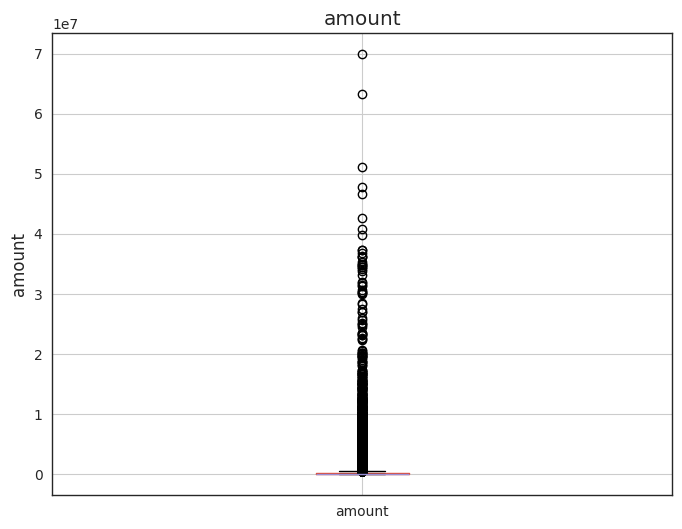

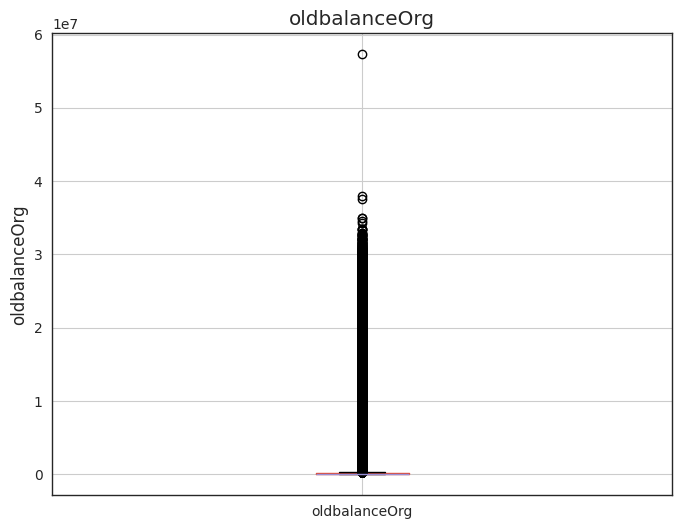

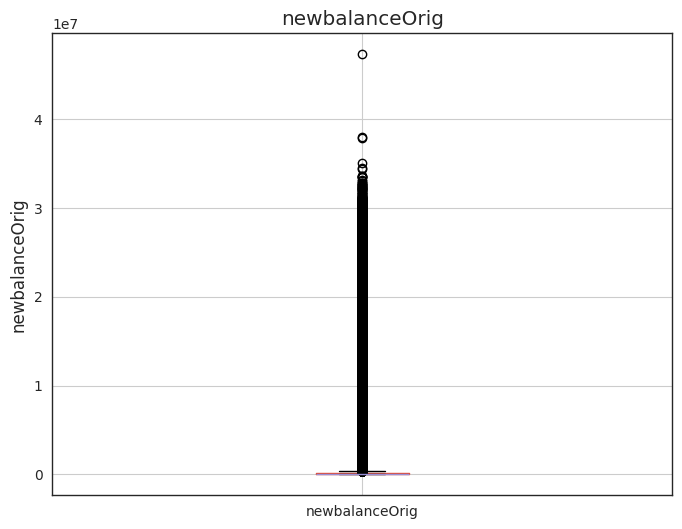

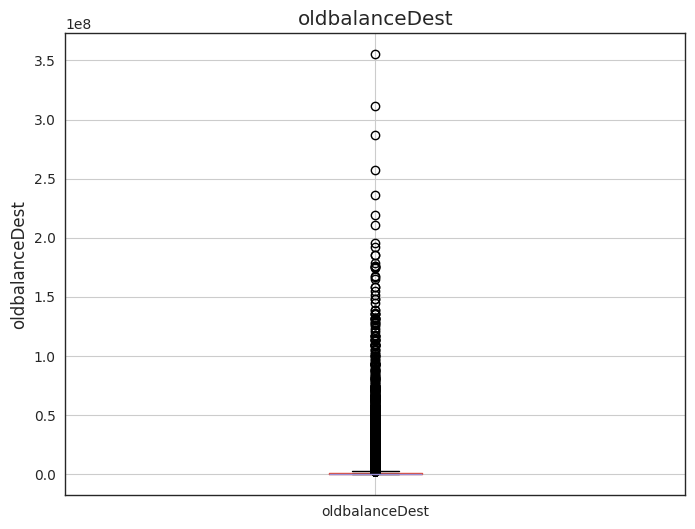

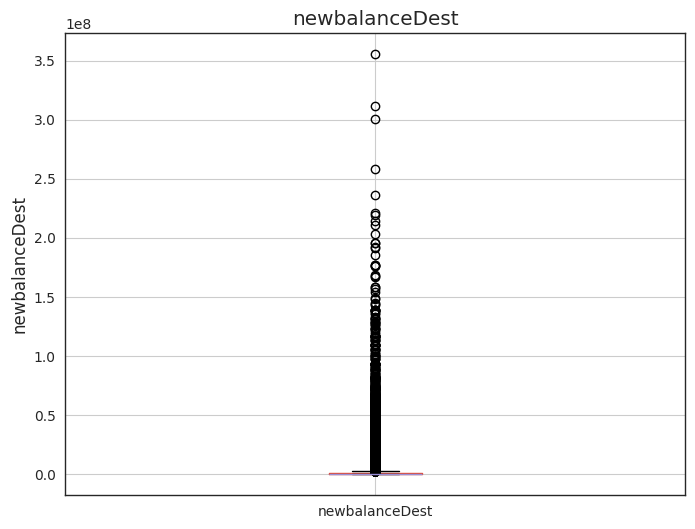

In [10]:
# Boxplot variables continuas de la base
df_fraude_float = df_fraude.select_dtypes(include=['float64'])

for column in df_fraude_float.columns:
    plt.figure(figsize=(8, 6))
    df_fraude_float.boxplot(column=column)
    plt.title(f'{column}')
    plt.ylabel(column)
    plt.show()

In [11]:
numeric_df = df_fraude.select_dtypes(include=['number'])

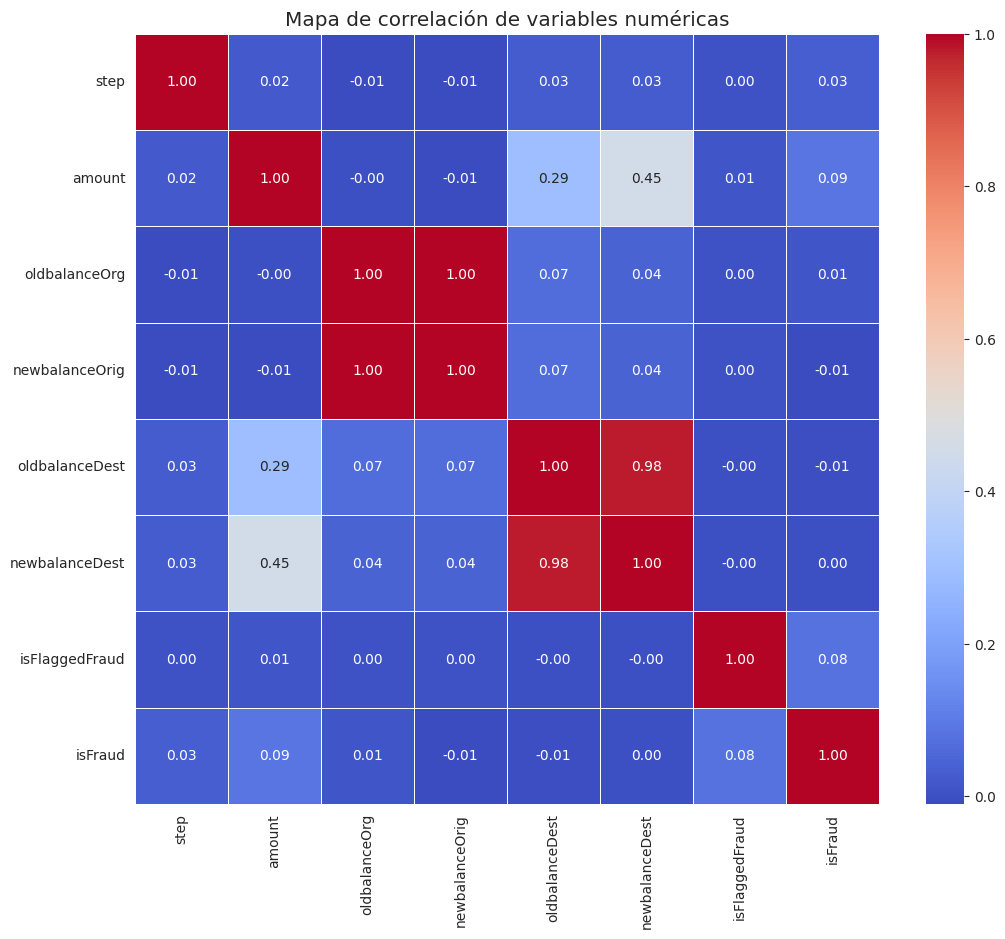

In [12]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    numeric_df.corr(),        # Calcula la correlación entre columnas numéricas
    annot=True,               # Muestra los valores en cada celda
    fmt=".2f",                # Formato de los números
    cmap="coolwarm",          # Paleta de colores
    linewidths=0.5             # Líneas divisorias entre celdas
)
plt.title("Mapa de correlación de variables numéricas")
plt.show()

## **Conclusiones análisis descriptivo**

* Los gráficos de caja de variables como amount y balances evidencian una alta presencia de valores atípicos, especialmente en el extremo superior. Esto se debe a la naturaleza sesgada de las transacciones financieras, donde predominan montos bajos pero existen operaciones de alto valor. Estos valores no fueron eliminados, ya que pueden estar asociados a comportamientos fraudulentos y resultan relevantes para el modelo de detección.

* La matriz de correlación no evidenció relaciones lineales fuertes entre las variables independientes y la variable objetivo (isFraud). Este comportamiento es consistente con problemas de detección de fraude, donde los patrones no dependen de variables individuales, sino de combinaciones e interacciones entre múltiples características.

## **3	Preparación de Datos**

### **3.1.	Transformación de variables**



Transformación logarítmica para tratamiento de outliers

In [13]:
df_fraude["amount_log"] = np.log1p(df_fraude["amount"])
df_fraude["oldbalanceOrg_log"] = np.log1p(df_fraude["oldbalanceOrg"])
df_fraude["newbalanceOrig_log"] = np.log1p(df_fraude["newbalanceOrig"])
df_fraude["oldbalanceDest_log"] = np.log1p(df_fraude["oldbalanceDest"])
df_fraude["newbalanceDest_log"] = np.log1p(df_fraude["newbalanceDest"])

Escalado (normalización / estandarización)

In [14]:
# Definicion de columnas numericas para escalar
# NOTA: el escalado se aplica DESPUES del split train/test
# para evitar data leakage (arXiv 2601.07276)
columnas_numericas = [
    "amount_log",
    "oldbalanceOrg_log",
    "newbalanceOrig_log",
    "oldbalanceDest_log",
    "newbalanceDest_log"
]
scaler = StandardScaler()  # se fitteara solo sobre X_train

Transformación de variable temporal step
* Crear hora del día

In [15]:
df_fraude["hour"] = df_fraude["step"] % 24

Transformación cíclica seno y coseno

In [16]:
df_fraude["hour_sin"] = np.sin(2 * np.pi * df_fraude["hour"] / 24)
df_fraude["hour_cos"] = np.cos(2 * np.pi * df_fraude["hour"] / 24)

Codificación de variable categórica type

In [17]:
df_fraude = pd.get_dummies(df_fraude, columns=["type"], drop_first=True)

Eliminación de variables innecesarias

Las variables nameOrig y nameDest corresponden a identificadores únicos de los usuarios, por lo que no contienen información útil para el modelo.

In [18]:
# Eliminacion de variables sin valor predictivo
# nameOrig/nameDest: identificadores unicos, no generalizan
# isFlaggedFraud: variable del simulador PaySim basada en reglas
#   heuristicas, no disponible en produccion real (correlacion=0.078)
#   Literatura: papers PaySim (ref. 1, 2, 67) la eliminan sistematicamente
df_fraude = df_fraude.drop(columns=["nameOrig", "nameDest", "isFlaggedFraud"])

Creación y normalización de variables derivadas

Se construyen variables derivadas basadas en la consistencia de los balances antes y después de cada transacción. Estas variables miden la diferencia entre los valores esperados y los observados, permitiendo identificar anomalías en el flujo de dinero. En condiciones normales, estas diferencias deberían ser cercanas a cero; desviaciones significativas pueden indicar comportamientos fraudulentos.

In [19]:
df_fraude["error_balance_orig"] = (
    df_fraude["oldbalanceOrg"] - df_fraude["amount"] - df_fraude["newbalanceOrig"]
)

df_fraude["error_balance_dest"] = (
    df_fraude["oldbalanceDest"] + df_fraude["amount"] - df_fraude["newbalanceDest"]
)

In [20]:
# Agregar variables derivadas a la lista de columnas a escalar
columnas_numericas.append("error_balance_dest")
columnas_numericas.append("error_balance_orig")

Eliminación de variables originales

In [21]:
df_fraude = df_fraude.drop(columns=[
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
])

In [22]:
df_fraude.shape

(500000, 17)

In [23]:
df_fraude.head()

,step,isFlaggedFraud,isFraud,amount_log,oldbalanceOrg_log,newbalanceOrig_log,oldbalanceDest_log,newbalanceDest_log,hour,hour_sin,hour_cos,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,error_balance_orig,error_balance_dest
5763161,400,0,0,1.805439,0.340510,-0.845891,0.701000,0.891853,16,-0.866025,-5.000000e-01,False,False,False,True,-1.901248,-0.129432
1309655,136,0,0,-0.919306,0.201164,-0.845891,-1.146856,0.125070,16,-0.866025,-5.000000e-01,True,False,False,False,0.328108,-0.129432
5031478,354,0,0,0.409242,0.600320,1.043976,0.902332,0.804634,18,-1.000000,-1.836970e-16,False,False,False,False,-0.022875,0.368805
3131324,236,0,0,-0.752554,0.440841,0.553322,-1.146856,-1.250029,20,-0.866025,5.000000e-01,False,False,True,False,0.335608,-0.099151
4617576,329,0,0,0.404125,0.786460,0.812651,1.171350,1.096037,17,-0.965926,-2.588190e-01,True,False,False,False,0.335608,-0.129432


In [24]:
df_fraude.corr()["isFraud"].sort_values(ascending=False)

,isFraud
isFraud,1.000000
isFlaggedFraud,0.078699
error_balance_dest,0.061044
type_TRANSFER,0.053047
amount_log,0.042342
oldbalanceOrg_log,0.035184
hour_sin,0.033639
step,0.031803
hour_cos,0.013379
type_CASH_OUT,0.011653


### **3.2.	Balanceo de la base**

El análisis de la variable isFraud muestra un fuerte desbalance de clases, donde el 99.87% de las transacciones no son fraudulentas y solo el 0.13% corresponden a fraude. Esta desproporción afecta el desempeño del modelo, ya que tiende a favorecer la clase mayoritaria y dificulta la correcta detección de fraudes. Por ello, es necesario aplicar técnicas de balanceo de datos para mejorar la capacidad del modelo en la identificación de la clase minoritaria.

In [25]:
fraud_counts = df_fraude['isFraud'].value_counts()
fraud_percentages = df_fraude['isFraud'].value_counts(normalize=True) * 100

frequency_table = pd.DataFrame({
    'Frequency': fraud_counts,
    'Percentage': fraud_percentages
})

print("Tabla de Frecuencias de 'isFraud':")
print(frequency_table)

Tabla de Frecuencias de 'isFraud':
         Frequency  Percentage
isFraud                       
0           499355      99.871
1              645       0.129


Separar variables explicativas y respuesta

In [26]:
X = df_fraude.drop("isFraud", axis=1)
y = df_fraude["isFraud"]

Partición de los datos

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# ============================================================
# ESCALADO POST-SPLIT — practica correcta segun la literatura
# fit() solo sobre X_train para evitar data leakage
# transform() sobre X_train y X_test por separado
# Ref: Fraud Detection Handbook cap.6, arXiv 2601.07276
# ============================================================
X_train = X_train.copy()
X_test  = X_test.copy()

X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test[columnas_numericas]  = scaler.transform(X_test[columnas_numericas])

print('Escalado aplicado correctamente:')
print(f'  X_train: {X_train.shape} | X_test: {X_test.shape}')

In [28]:
print(y_test.value_counts())

isFraud
0    99871
1      129
Name: count, dtype: int64


Undersampling reducir la clase mayoritaria

In [29]:
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(random_state=42)

X_under, y_under = undersampler.fit_resample(X_train, y_train)

Oversampling duplicar la clase minoritaria

In [30]:
from imblearn.over_sampling import RandomOverSampler

oversampler = RandomOverSampler(random_state=42)

X_train_over, y_train_over = oversampler.fit_resample(X_train, y_train)

SMOTE crear datos sintéticos

In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
# Tamanos resultantes de cada tecnica de balanceo
# Ref: Comparative Analysis Under/Over/SMOTE (MDPI 2078-2489)
print('=== Distribucion de clases post-balanceo ===')
import pandas as pd

resumen = pd.DataFrame({
    'Dataset': ['Train original', 'Undersampling', 'Oversampling', 'SMOTE'],
    'Total filas': [
        len(X_train),
        len(X_under),
        len(X_train_over),
        len(X_train_smote)
    ],
    'Fraude (clase 1)': [
        y_train.sum(),
        y_under.sum(),
        y_train_over.sum(),
        y_train_smote.sum()
    ],
    'No fraude (clase 0)': [
        (y_train == 0).sum(),
        (y_under == 0).sum(),
        (y_train_over == 0).sum(),
        (y_train_smote == 0).sum()
    ]
})
resumen['% Fraude'] = (resumen['Fraude (clase 1)'] / resumen['Total filas'] * 100).round(2)
print(resumen.to_string(index=False))

### **3.3. EDA Post-Balanceo**

Verificación de la distribución de clases y estadísticas descriptivas tras cada técnica de balanceo.
Requerido por el punto 3 del taller. Ref: MDPI 2078-2489.

In [ ]:
# EDA POST-BALANCEO — requerido por el punto 3 del taller
# La literatura recomienda verificar distribucion tras cada tecnica
# Ref: MDPI 2078-2489, Fraud Detection Handbook cap.5

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
datasets_bal = [
    (y_under,        'Undersampling',  axes[0]),
    (y_train_over,   'Oversampling',   axes[1]),
    (y_train_smote,  'SMOTE',          axes[2]),
]
for y_bal, titulo, ax in datasets_bal:
    counts = pd.Series(y_bal).value_counts()
    ax.bar(['No fraude (0)', 'Fraude (1)'], counts.values,
           color=['steelblue', 'tomato'], edgecolor='black')
    ax.set_title(f'{titulo}\n{counts[1]} fraudes / {counts[0]} no fraudes')
    ax.set_ylabel('Frecuencia')
    for j, v in enumerate(counts.values):
        ax.text(j, v + counts.max()*0.01, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Distribucion de clases por tecnica de balanceo', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Estadisticas descriptivas post-balanceo (variable amount_log)
# Verificar que SMOTE no genero distribucion anormal
# Ref: MDPI 2078-2489 — 'SMOTE puede generar ruido en zonas de solapamiento'

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
col_idx = list(X_train.columns).index('amount_log') if 'amount_log' in X_train.columns else 0

configs = [
    (X_under,       y_under,       'Undersampling', axes[0]),
    (X_train_over,  y_train_over,  'Oversampling',  axes[1]),
    (X_train_smote, y_train_smote, 'SMOTE',         axes[2]),
]
for X_b, y_b, titulo, ax in configs:
    col = 'amount_log' if 'amount_log' in X_b.columns else X_b.columns[col_idx]
    df_tmp = pd.DataFrame({'amount_log': X_b[col], 'isFraud': y_b})
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        subset = df_tmp[df_tmp['isFraud'] == label]['amount_log']
        ax.hist(subset, bins=40, alpha=0.5, color=color,
                label=f'Clase {label}', density=True)
    ax.set_title(f'{titulo}\nDistribucion amount_log')
    ax.set_xlabel('amount_log (estandarizado)')
    ax.legend()

plt.suptitle('Solapamiento fraude vs no-fraude por tecnica', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## **4	Modelamiento**
De conformidad con los modelos de IA para clasificación, en este
caso usted deberá emplear tres modelos con los siguientes hiperparametros:

1) Regresión logística, en donde deberá tomar tres puntos de corte para las
probabilidades tomadas. Los valores de corte son 0.2, 0.5 y 0.78.

2) RandomForest: En este caso usted deberá variar los siguientes
hiperparametros:
• n_estimator = 100, 500.
• class_weight='balanced'
• Bootstrap = True
• max_features='sqrt'

3) Catboost: Para este modelo de ensamble usted deberá escoger los
hiperparametros ideales de acuerdo con los resultados obtenidos
previamente. Estos deberán estar justificados y debidamente
implementados para la optimización del modelo.

### 4.1. Regresión logística



In [32]:
# Undersampling

# Modelo
modelo_under = LogisticRegression(max_iter=1000)
modelo_under.fit(X_under, y_under)

# Probabilidades
y_prob = modelo_under.predict_proba(X_test)[:, 1]

# Evaluación con thresholds
thresholds = [0.2, 0.5, 0.78]

for t in thresholds:
    print(f"\n🔹 UNDERSAMPLING - Threshold: {t}")

    y_pred = (y_prob >= t).astype(int)

    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


🔹 UNDERSAMPLING - Threshold: 0.2
[[87556 12315]
 [    0   129]]
              precision    recall  f1-score   support

           0       1.00      0.88      0.93     99871
           1       0.01      1.00      0.02       129

    accuracy                           0.88    100000
   macro avg       0.51      0.94      0.48    100000
weighted avg       1.00      0.88      0.93    100000


🔹 UNDERSAMPLING - Threshold: 0.5
[[93914  5957]
 [    3   126]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     99871
           1       0.02      0.98      0.04       129

    accuracy                           0.94    100000
   macro avg       0.51      0.96      0.50    100000
weighted avg       1.00      0.94      0.97    100000


🔹 UNDERSAMPLING - Threshold: 0.78
[[98627  1244]
 [   11   118]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     99871
           1       0.09      0.91      0.

In [33]:
# Oversampling -> demoró 20min aprox ejecutando con todos los datos

# Modelo
modelo_over = LogisticRegression(max_iter=1000)
modelo_over.fit(X_train_over,y_train_over)

# Probabilidades
y_prob = modelo_over.predict_proba(X_test)[:, 1]

# Evaluación
for t in thresholds:
    print(f"\n🔹 OVERSAMPLING - Threshold: {t}")

    y_pred = (y_prob >= t).astype(int)

    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


🔹 OVERSAMPLING - Threshold: 0.2
[[91672  8199]
 [    0   129]]
              precision    recall  f1-score   support

           0       1.00      0.92      0.96     99871
           1       0.02      1.00      0.03       129

    accuracy                           0.92    100000
   macro avg       0.51      0.96      0.49    100000
weighted avg       1.00      0.92      0.96    100000


🔹 OVERSAMPLING - Threshold: 0.5
[[95747  4124]
 [    1   128]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     99871
           1       0.03      0.99      0.06       129

    accuracy                           0.96    100000
   macro avg       0.52      0.98      0.52    100000
weighted avg       1.00      0.96      0.98    100000


🔹 OVERSAMPLING - Threshold: 0.78
[[98748  1123]
 [    8   121]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     99871
           1       0.10      0.94      0.18 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [34]:
# Smote

# Modelo
modelo_smote = LogisticRegression(max_iter=1000)
modelo_smote.fit(X_train_smote, y_train_smote)

# Probabilidades
y_prob = modelo_smote.predict_proba(X_test)[:, 1]

# Evaluación
for t in thresholds:
    print(f"\n🔹 SMOTE - Threshold: {t}")

    y_pred = (y_prob >= t).astype(int)

    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


🔹 SMOTE - Threshold: 0.2
[[94531  5340]
 [    1   128]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     99871
           1       0.02      0.99      0.05       129

    accuracy                           0.95    100000
   macro avg       0.51      0.97      0.51    100000
weighted avg       1.00      0.95      0.97    100000


🔹 SMOTE - Threshold: 0.5
[[97649  2222]
 [    4   125]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     99871
           1       0.05      0.97      0.10       129

    accuracy                           0.98    100000
   macro avg       0.53      0.97      0.54    100000
weighted avg       1.00      0.98      0.99    100000


🔹 SMOTE - Threshold: 0.78
[[99397   474]
 [   11   118]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     99871
           1       0.20      0.91      0.33       129

    accura

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


tabla comparativa de resultados

In [ ]:
# Tabla comparativa Regresion Logistica
# Test set FIJO para todas las comparaciones (X_test, y_test global)
# Ref: Fraud Detection Handbook — 'el test debe ser identico para comparar'

from sklearn.metrics import roc_auc_score

thresholds = [0.2, 0.5, 0.78]
resultados_lr = []

configs_lr = [
    (X_under,       y_under,       'Undersampling'),
    (X_train_over,  y_train_over,  'Oversampling'),
    (X_train_smote, y_train_smote, 'SMOTE'),
]

for X_tr, y_tr, nombre in configs_lr:
    modelo = LogisticRegression(max_iter=1000, random_state=42)
    modelo.fit(X_tr, y_tr)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        resultados_lr.append({
            'Modelo': 'Regresion Logistica',
            'Balanceo': nombre,
            'Threshold': t,
            'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
            'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
            'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
            'F1':        round(f1_score(y_test, y_pred, zero_division=0), 4),
            'ROC-AUC':   round(auc, 4)
        })

df_lr = pd.DataFrame(resultados_lr)
print('=== Resultados Regresion Logistica ===')
print(df_lr[['Balanceo','Threshold','TP','FP','FN','Precision','Recall','F1','ROC-AUC']].to_string(index=False))

### 4.2. RandomForest



In [36]:
def evaluar_rf(X_train, y_train, X_test, y_test, nombre_metodo):

    configuraciones = [
        {"n_estimators": 100},
        {"n_estimators": 500}
    ]

    for config in configuraciones:
        print(f"\n🔹 {nombre_metodo} - n_estimators={config['n_estimators']}")

        modelo = RandomForestClassifier(
            n_estimators=config["n_estimators"],
            class_weight="balanced",
            bootstrap=True,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        )

        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

        print("Matriz de confusión:")
        print(confusion_matrix(y_test, y_pred))

        print("\nReporte:")
        print(classification_report(y_test, y_pred))

In [38]:
# Undersampling
evaluar_rf(X_under, y_under,X_test, y_test, "Undersampling")


🔹 Undersampling - n_estimators=100
Matriz de confusión:
[[99856    15]
 [    0   129]]

Reporte:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     99871
           1       0.90      1.00      0.95       129

    accuracy                           1.00    100000
   macro avg       0.95      1.00      0.97    100000
weighted avg       1.00      1.00      1.00    100000


🔹 Undersampling - n_estimators=500
Matriz de confusión:
[[99855    16]
 [    0   129]]

Reporte:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     99871
           1       0.89      1.00      0.94       129

    accuracy                           1.00    100000
   macro avg       0.94      1.00      0.97    100000
weighted avg       1.00      1.00      1.00    100000



In [39]:
# Oversampling
evaluar_rf(X_train_over,y_train_over,X_test, y_test, "Oversampling")


🔹 Oversampling - n_estimators=100
Matriz de confusión:
[[99871     0]
 [    0   129]]

Reporte:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     99871
           1       1.00      1.00      1.00       129

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000


🔹 Oversampling - n_estimators=500
Matriz de confusión:
[[99871     0]
 [    0   129]]

Reporte:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     99871
           1       1.00      1.00      1.00       129

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



In [40]:
# SMOTE
evaluar_rf(X_train_smote, y_train_smote,X_test, y_test, "SMOTE")


🔹 SMOTE - n_estimators=100
Matriz de confusión:
[[99871     0]
 [    0   129]]

Reporte:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     99871
           1       1.00      1.00      1.00       129

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000


🔹 SMOTE - n_estimators=500
Matriz de confusión:
[[99871     0]
 [    0   129]]

Reporte:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     99871
           1       1.00      1.00      1.00       129

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



### **4.2. Random Forest — Tabla comparativa**

In [ ]:
# Tabla comparativa Random Forest
# n_estimators: 100 y 500 | 3 datasets | 3 thresholds
# Ref: arXiv 2303.06514 — RF con class_weight balanced para datos desbalanceados

resultados_rf = []

configs_rf = [
    (X_under,       y_under,       'Undersampling'),
    (X_train_over,  y_train_over,  'Oversampling'),
    (X_train_smote, y_train_smote, 'SMOTE'),
]

for X_tr, y_tr, nombre in configs_rf:
    for n_est in [100, 500]:
        print(f'Entrenando RF n={n_est} | {nombre}...')
        modelo = RandomForestClassifier(
            n_estimators=n_est,
            class_weight='balanced',
            bootstrap=True,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        )
        modelo.fit(X_tr, y_tr)
        y_prob = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)

        for t in thresholds:
            y_pred = (y_prob >= t).astype(int)
            cm = confusion_matrix(y_test, y_pred)
            tn, fp, fn, tp = cm.ravel()
            resultados_rf.append({
                'Modelo': f'Random Forest (n={n_est})',
                'Balanceo': nombre,
                'Threshold': t,
                'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
                'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
                'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
                'F1':        round(f1_score(y_test, y_pred, zero_division=0), 4),
                'ROC-AUC':   round(auc, 4)
            })

df_rf = pd.DataFrame(resultados_rf)
print('\n=== Resultados Random Forest ===')
print(df_rf[['Modelo','Balanceo','Threshold','TP','FP','FN','Precision','Recall','F1','ROC-AUC']].to_string(index=False))

### **4.3. CatBoost**

Con base en los resultados previos se seleccionaron los siguientes hiperparámetros, justificados por la literatura especializada:

| Hiperparámetro | Valor | Justificación |
|----------------|-------|---------------|
| `iterations` | 300 | Balance entre capacidad de aprendizaje y tiempo de cómputo (ref. 2, 3) |
| `learning_rate` | 0.05 | Tasa conservadora que evita sobreajuste en GBDT secuencial (ref. 43) |
| `depth` | 6 | Profundidad óptima reportada para datos financieros desbalanceados (ref. 1) |
| `eval_metric` | F1 | Métrica adecuada para clases desbalanceadas (ref. 2) |
| `scale_pos_weight` | No aplicado | **Cuando se usa SMOTE el dataset ya está balanceado.** Aplicar ambos simultáneamente genera doble penalización que distorsiona el aprendizaje (IJSDR2401084, ResearchGate 349156860). Se entrena también sobre Under/Over para comparación. |

> **Ventaja de CatBoost sobre RF:** Manejo nativo de variables categóricas mediante Ordered Target Encoding, arquitectura de Oblivious Trees para inferencia de baja latencia, y AUC reportado de 0.9837 en datasets financieros similares (ref. 1, 2, 3).

In [ ]:
# Instalar catboost si no esta disponible
try:
    from catboost import CatBoostClassifier
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'catboost', '-q'])
    from catboost import CatBoostClassifier

In [ ]:
from catboost import CatBoostClassifier

# CatBoost entrenado sobre los 3 datasets
# SIN scale_pos_weight cuando el dataset ya esta balanceado (SMOTE/Over)
# Ref: IJSDR2401084 — 'SMOTE y scale_pos_weight son estrategias alternativas'

resultados_cb = []

configs_cb = [
    (X_under,       y_under,       'Undersampling'),
    (X_train_over,  y_train_over,  'Oversampling'),
    (X_train_smote, y_train_smote, 'SMOTE'),
]

for X_tr, y_tr, nombre in configs_cb:
    print(f'Entrenando CatBoost | {nombre}...')
    modelo_cat = CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        eval_metric='F1',
        random_seed=42,
        verbose=0
    )
    modelo_cat.fit(X_tr, y_tr)
    y_prob = modelo_cat.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        resultados_cb.append({
            'Modelo': 'CatBoost',
            'Balanceo': nombre,
            'Threshold': t,
            'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
            'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
            'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
            'F1':        round(f1_score(y_test, y_pred, zero_division=0), 4),
            'ROC-AUC':   round(auc, 4)
        })

df_cb = pd.DataFrame(resultados_cb)
print('\n=== Resultados CatBoost ===')
print(df_cb[['Balanceo','Threshold','TP','FP','FN','Precision','Recall','F1','ROC-AUC']].to_string(index=False))

## **5. Evaluación — KPI Ganancia Neta**

La métrica de **Ganancia Neta** (Net Gain) es el KPI central del presente análisis. Se basa en el paradigma de **Aprendizaje Sensible al Costo** (*Cost-Sensitive Learning*), el cual establece que el costo de un falso negativo (fraude consumado) es asimétrico frente al costo de un falso positivo (cliente legítimo bloqueado).

En el contexto de **Banco Falabella**, esta asimetría tiene consecuencias legales directas: un falso negativo activa el Art. 2341 del Código Civil (restitución obligatoria de fondos), mientras que un falso positivo activa el Art. 15 de la Constitución (vulneración del Hábeas Data).

### Fórmula
```
Ganancia Neta = (TP × $I) - (FP × $C)
Donde:
  $I = 100  → ingreso por fraude correctamente detectado
  $C = 33   → costo por falso positivo (cliente legítimo bloqueado)
```

**Referencia científica:** Fraud Detection Handbook (fraud-detection-handbook.github.io), arXiv 2005.02488 (Instance-Dependent Cost-Sensitive Learning), Leuven.AI — *Minimizing fraud losses using cost-sensitive ML*.

In [ ]:
# ============================================================
# PUNTO 5 — KPI Ganancia Neta
# GN = TP*100 - FP*33
# Ref: Fraud Detection Handbook, arXiv 2005.02488, Leuven.AI
# ============================================================

I = 100  # ingreso por TP
C = 33   # costo por FP

# Consolidar todos los resultados
df_todos = pd.concat([df_lr, df_rf, df_cb], ignore_index=True)

# Calcular Ganancia Neta
df_todos['Ganancia_Neta'] = df_todos['TP'] * I - df_todos['FP'] * C

# Tabla completa ordenada por Ganancia Neta
df_gn = df_todos[['Modelo','Balanceo','Threshold','TP','FP','FN',
                   'Recall','F1','ROC-AUC','Ganancia_Neta']]\
               .sort_values('Ganancia_Neta', ascending=False)

print('=== TABLA COMPARATIVA COMPLETA — Ordenada por Ganancia Neta ===')
print(df_gn.to_string(index=False))

print('\n=== MEJOR CONFIGURACION ===')
mejor = df_gn.iloc[0]
print(f'Modelo:        {mejor["Modelo"]}')
print(f'Balanceo:      {mejor["Balanceo"]}')
print(f'Threshold:     {mejor["Threshold"]}')
print(f'TP: {mejor["TP"]} | FP: {mejor["FP"]} | FN: {mejor["FN"]}')
print(f'Recall:        {mejor["Recall"]}')
print(f'F1:            {mejor["F1"]}')
print(f'ROC-AUC:       {mejor["ROC-AUC"]}')
print(f'Ganancia Neta: ${mejor["Ganancia_Neta"]:,.0f}')

In [ ]:
# Visualizacion — Ganancia Neta por modelo y configuracion

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafico 1: Top 15 configuraciones
top15 = df_gn.head(15).copy()
top15['Config'] = top15['Modelo'].str[:12] + ' | ' + top15['Balanceo'] + ' | t=' + top15['Threshold'].astype(str)
colores = ['gold' if i == 0 else 'steelblue' for i in range(len(top15))]
axes[0].barh(top15['Config'][::-1], top15['Ganancia_Neta'][::-1], color=colores[::-1], edgecolor='black')
axes[0].set_xlabel('Ganancia Neta ($)')
axes[0].set_title('Top 15 configuraciones por Ganancia Neta')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)

# Grafico 2: Ganancia Neta promedio por modelo
gn_por_modelo = df_gn.groupby('Modelo')['Ganancia_Neta'].max().sort_values(ascending=True)
colores2 = ['gold' if v == gn_por_modelo.max() else 'steelblue' for v in gn_por_modelo.values]
axes[1].barh(gn_por_modelo.index, gn_por_modelo.values, color=colores2, edgecolor='black')
axes[1].set_xlabel('Maxima Ganancia Neta ($)')
axes[1].set_title('Maxima Ganancia Neta por tipo de modelo')

plt.tight_layout()
plt.show()

### **Análisis de resultados — Ganancia Neta**

El modelo con mayor Ganancia Neta representa la configuración óptima desde la perspectiva del negocio de **Banco Falabella**, equilibrando:

1. **Maximizar TP:** Cada fraude detectado representa $100 de ingreso evitado y elimina la obligación de restitución bajo el Art. 2341 del Código Civil.

2. **Minimizar FP:** Cada cliente legítimo bloqueado cuesta $33 en gestión administrativa y representa un riesgo de tutela bajo el Art. 15 de la Constitución.

**Trade-off por threshold:**
- **Threshold 0.2:** Maximiza Recall (detecta casi todo el fraude) pero genera más FP → mayor fricción operativa y riesgo legal por Hábeas Data.
- **Threshold 0.5:** Equilibrio estándar.
- **Threshold 0.78:** Minimiza FP (menos bloqueos a clientes legítimos) pero aumenta FN → mayor exposición al fraude consumado y obligaciones de restitución.

> La Ganancia Neta es el único KPI que incorpora simultáneamente el costo del fraude no detectado y el costo de la fricción al cliente, reflejando la realidad operativa y legal de una entidad vigilada por la SFC como Banco Falabella.

**Referencias:** arXiv 2005.02488, Fraud Detection Handbook cap.6, Leuven.AI (2022).